<a href="https://colab.research.google.com/github/Givi-Modebadze/ML_Final_Project/blob/main/experiments/Sarima_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'ML_Final_Project/walmart-recruiting-store-sales-forecasting'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/ML_Final_Project/walmart-recruiting-store-sales-forecasting


In [2]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


# Merge data

In [3]:
df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

def merger(df, stores, features):
    df = df.merge(stores, how='left', on='Store')
    df = df.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
    return df

df = merger(df, stores, features)
test = merger(test, stores, features)

df.sort_values('Date', inplace=True)
test.sort_values('Date', inplace=True)

y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])
dates = df['Date']

# print(df.head())
# print(test.head())

# Preprocessor

In [4]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.type_encoder = None  # for 'Type' column

    def fit(self, X: pd.DataFrame, y=None):
        # Fit label encoder on 'Type'
        if 'Type' in X.columns:
            self.type_encoder = X['Type'].astype('category').cat.categories
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        # Date features
        X['Date'] = pd.to_datetime(X['Date'])
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['Day'] = X['Date'].dt.day

        # Categorical: Type
        if self.type_encoder is not None:
            X['Type'] = pd.Categorical(X['Type'], categories=self.type_encoder)
            X['Type'] = X['Type'].cat.codes

        # Convert IsHoliday to int if not already
        if 'IsHoliday' in X.columns:
            X['IsHoliday'] = X['IsHoliday'].astype(int)

        # Fill NA values
        # X = X.fillna(0)


        return X


# cross validation

In [5]:
def weighted_mae(y_true, y_pred, is_holiday):
    weights = is_holiday * 4 + 1
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

def cross_validation(pipeline, X, y, df_with_dates):
    from matplotlib.dates import DateFormatter

    tscv = TimeSeriesSplit(n_splits=8)
    rmse_scores = []
    wmae_scores = []
    train_rmse_scores = []
    train_wmae_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        if fold < 4:
            continue

        # Clone the pipeline to avoid the warning
        pipeline_clone = clone(pipeline)

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Fit the pipeline
        pipeline_clone.fit(X_train, y_train)

        # Predictions
        y_val_pred = pipeline_clone.predict(X_val)
        y_train_pred = pipeline_clone.predict(X_train)

        # RMSE
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

        # WMAE
        val_is_holiday = df_with_dates.iloc[val_idx]['IsHoliday'].astype(int)
        train_is_holiday = df_with_dates.iloc[train_idx]['IsHoliday'].astype(int)

        val_wmae = weighted_mae(y_val, y_val_pred, val_is_holiday)
        train_wmae = weighted_mae(y_train, y_train_pred, train_is_holiday)

        print(f"\nFold {fold + 1} Scores:")
        print(f"Train RMSE: {train_rmse:.2f} | Train WMAE: {train_wmae:.2f}")
        print(f"Valid RMSE: {val_rmse:.2f} | Valid WMAE: {val_wmae:.2f}")

        rmse_scores.append(val_rmse)
        wmae_scores.append(val_wmae)
        train_rmse_scores.append(train_rmse)
        train_wmae_scores.append(train_wmae)

        # --- Plotting ---
        df_all = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates['Date']),
            'y': y.values
        })
        df_all = df_all.groupby('Date').sum().reset_index().sort_values('Date')

        df_val = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[val_idx]['Date']),
            'Actual': y_val.values,
            'Predicted': y_val_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        df_train = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[train_idx]['Date']),
            'Actual': y_train.values,
            'Predicted': y_train_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        plt.figure(figsize=(12, 4))

        # Train actuals
        plt.plot(df_all['Date'], df_all['y'], color='gray', label='Train Actuals', linewidth=1.5, alpha=0.4)

        # Train predictions
        plt.plot(df_train['Date'], df_train['Predicted'], color='green', label='Train Predicted', linewidth=1.5, alpha=0.8)

        # Validation actuals
        plt.plot(df_val['Date'], df_val['Actual'], color='blue', label='Val Actuals', linewidth=2)

        # Validation predictions
        plt.plot(df_val['Date'], df_val['Predicted'], color='orange', label='Val Predicted', linewidth=2)

        plt.title(f'Fold {fold + 1} - Weekly Sales Over Time', fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Weekly Sales")
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # --- Averages ---
    print(f"\nMean Train RMSE: {np.mean(train_rmse_scores):.2f}")
    print(f"Mean Train WMAE: {np.mean(train_wmae_scores):.2f}")
    print(f"Mean Valid RMSE: {np.mean(rmse_scores):.2f}")
    print(f"Mean Valid WMAE: {np.mean(wmae_scores):.2f}")

# Pipeline

In [8]:
from sklearn.base import BaseEstimator, RegressorMixin
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

class SARIMARegressor(BaseEstimator, RegressorMixin):
    def __init__(self, order=(1, 1, 1), seasonal_order=(0, 1, 1, 52)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.models = {}
        self.mean_value = None
        self.store_means = {}
        self.avg_dept_per_store = None

    def fit(self, X, y):
        self.mean_value = np.mean(y)

        df_temp = X.copy()
        df_temp['y'] = y
        df_temp['Date'] = pd.to_datetime(df_temp['Date'])
        df_temp = df_temp.sort_values('Date')

        self.avg_dept_per_store = df_temp.groupby('Store')['Dept'].nunique().mean()

        for store, group in df_temp.groupby(['Store']):
            key = f"store_{store}"

            ts = group.groupby('Date')['y'].sum().sort_index()
            self.store_means[key] = ts.mean()

            try:
                min_obs = max(3 * self.seasonal_order[3], 156)
                if len(ts) >= min_obs:
                    ts.index.freq = 'W-FRI'

                    model = SARIMAX(ts, order=self.order, seasonal_order=self.seasonal_order,
                                  enforce_stationarity=False, enforce_invertibility=False)
                    fitted_model = model.fit(disp=False)
                    self.models[key] = fitted_model
            except:
                pass

        return self

    def predict(self, X):
        predictions = []

        for idx, row in X.iterrows():
            store_key = f"store_{row['Store']}"

            if store_key in self.models:
                try:
                    forecast = self.models[store_key].forecast(steps=1)
                    store_forecast = forecast.iloc[0] if hasattr(forecast, 'iloc') else forecast[0]

                    prediction = store_forecast / self.avg_dept_per_store
                    predictions.append(max(0, prediction))
                except:
                    predictions.append(self.store_means.get(store_key, self.mean_value))
            else:
                predictions.append(self.mean_value)

        return np.array(predictions)


Fold 5 Scores:
Train RMSE: 22495.62 | Train WMAE: 15159.56
Valid RMSE: 23718.75 | Valid WMAE: 16018.71


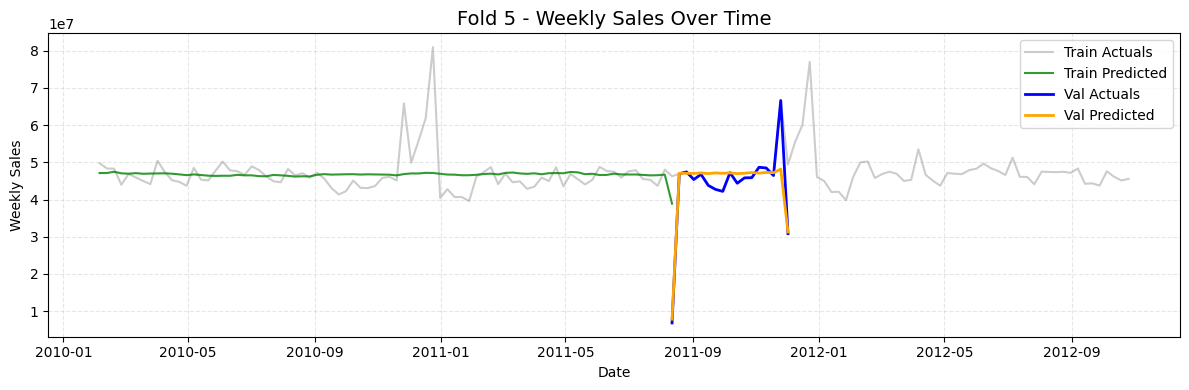


Fold 6 Scores:
Train RMSE: 22704.05 | Train WMAE: 15326.11
Valid RMSE: 24115.90 | Valid WMAE: 15550.82


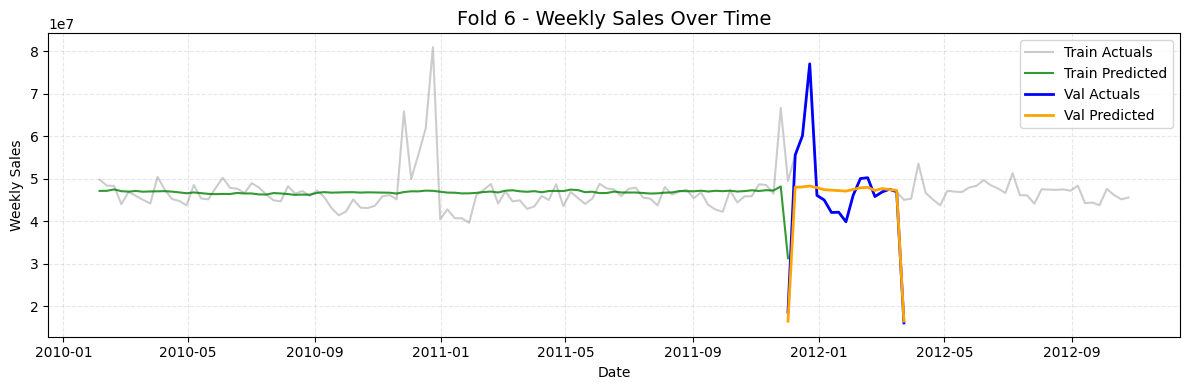


Fold 7 Scores:
Train RMSE: 22910.90 | Train WMAE: 15395.53
Valid RMSE: 22126.21 | Valid WMAE: 15213.39


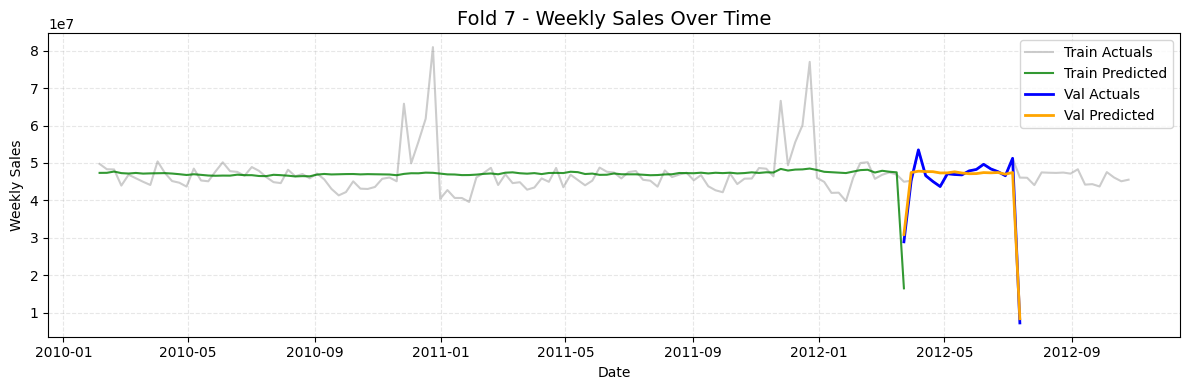


Fold 8 Scores:
Train RMSE: 22814.29 | Train WMAE: 15378.15
Valid RMSE: 21869.06 | Valid WMAE: 15128.42


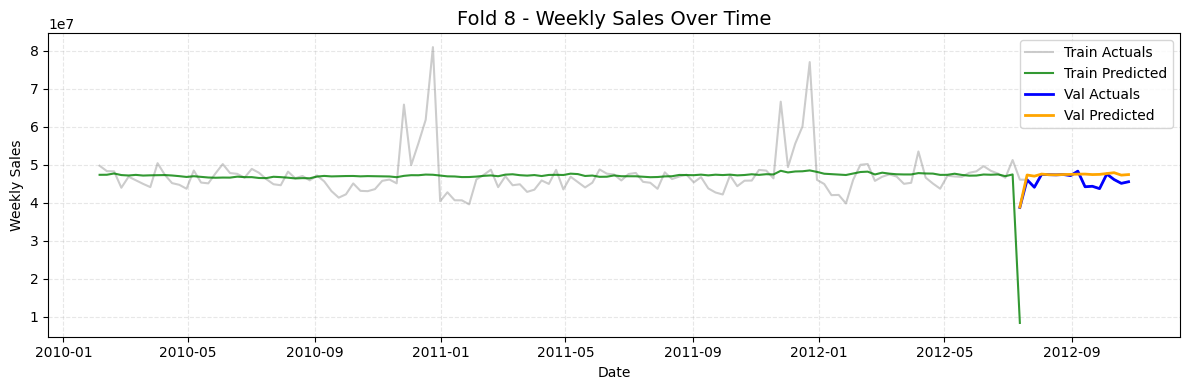


Mean Train RMSE: 22731.21
Mean Train WMAE: 15314.84
Mean Valid RMSE: 22957.48
Mean Valid WMAE: 15477.84


{'train_rmse': [np.float64(22495.61619450385),
  np.float64(22704.047553421904),
  np.float64(22910.898629148345),
  np.float64(22814.288949725662)],
 'train_wmae': [np.float64(15159.558240621926),
  np.float64(15326.111112743982),
  np.float64(15395.534232910404),
  np.float64(15378.146005874418)],
 'val_rmse': [np.float64(23718.75051156231),
  np.float64(24115.900298296736),
  np.float64(22126.211203801275),
  np.float64(21869.055707479794)],
 'val_wmae': [np.float64(16018.708409206034),
  np.float64(15550.823698986716),
  np.float64(15213.390039095339),
  np.float64(15128.420839051014)]}

In [9]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

preprocessor = Preprocessor()
model = SARIMARegressor()

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

cross_validation(pipeline, X, y, df)

In [ ]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor', Preprocessor()), ('model', ARIMARegressor())])